# SHAP Analysis for JSP Complexity (CP-oriented)

This notebook loads graph-based instance features from `./graphs/features.json` and a complexity label in `[0,1]` from `./graphs/complexity_scores.csv` (column `complexity_0_1`).  
If the label file is not found, it will **compute an unsupervised complexity** signal as a proxy (ensemble of IsolationForest, LOF, robust Mahalanobis and kNN density), and use that as the target to explain.

> Intended workflow: run your complexity estimation first to create `complexity_scores.csv`, then use this notebook to **explain** which features drive complexity via **SHAP**.


## Requirements

- Python 3.8+
- `numpy`, `pandas`, `scikit-learn`, `matplotlib`
- `shap` (for explanations). If you don't have it, install with:

```bash
pip install shap
```

> Note: Internet access may be required to install packages in your local environment.


In [2]:
import os, json, math, warnings
import numpy as np
import pandas as pd
from typing import Dict, Any
from tqdm.auto import tqdm

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors
from sklearn.covariance import MinCovDet
from sklearn.ensemble import IsolationForest, RandomForestRegressor
from scipy.stats import spearmanr

import matplotlib.pyplot as plt
import shap

warnings.filterwarnings("ignore")
np.set_printoptions(edgeitems=3, suppress=True)

FEATURES_PATH = "./graphs/features.json"
LABELS_PATH = "./graphs/complexity_scores.csv"  # expects 'complexity_0_1'
os.makedirs("./graphs", exist_ok=True)


def _to_float(v):
    try:
        if v is None:
            return np.nan
        if isinstance(v, (int, float, np.number)):
            return float(v)
        if isinstance(v, str) and v.strip().lower() in {"nan", "none", "null", ""}:
            return np.nan
        return float(v)
    except Exception:
        return np.nan


def _safe_minmax(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    if x.size == 0:
        return x
    xmin = np.nanmin(x)
    xmax = np.nanmax(x)
    if not np.isfinite(xmin) or not np.isfinite(xmax) or abs(xmax - xmin) < 1e-12:
        return np.zeros_like(x, dtype=float)
    return (x - xmin) / (xmax - xmin)


def load_features_json(path=FEATURES_PATH) -> pd.DataFrame:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Features file not found: {path}")
    with open(path, "r", encoding="utf-8") as f:
        raw = json.load(f)
    rows = []
    for inst_id, rec in raw.items():
        if (
            isinstance(rec, dict)
            and "features" in rec
            and isinstance(rec["features"], dict)
        ):
            rec = rec["features"]
        numeric = {k: _to_float(v) for k, v in rec.items()}
        numeric["instance_id"] = inst_id
        rows.append(numeric)
    df = pd.DataFrame(rows).set_index("instance_id")
    df = df.dropna(axis=1, how="all")
    return df


def build_matrix(df: pd.DataFrame):

    cols = [c for c in df.columns if "betweenness" not in c or c != "seed"]

    X = df[cols].select_dtypes(include=[np.number]).copy()
    imputer = SimpleImputer(strategy="median")
    scaler = RobustScaler()
    X_imp = imputer.fit_transform(X.values)
    X_scl = scaler.fit_transform(X_imp)
    return X, X_scl, imputer, scaler


def unsupervised_complexity(
    X_scl: np.ndarray, random_state=42
) -> Dict[str, np.ndarray]:
    n = X_scl.shape[0]
    # 1) Isolation Forest
    iforest = IsolationForest(n_estimators=400, random_state=random_state, n_jobs=-1)
    iforest.fit(X_scl)
    s_if = -iforest.score_samples(X_scl)
    s_if = _safe_minmax(s_if)
    # 2) LOF
    lof = LocalOutlierFactor(
        n_neighbors=min(20, max(5, int(math.sqrt(n)))), contamination="auto"
    )
    lof.fit(X_scl)
    s_lof = -lof.negative_outlier_factor_
    s_lof = _safe_minmax(s_lof)
    # 3) Robust Mahalanobis
    mcd = MinCovDet(random_state=random_state)
    mcd.fit(X_scl)
    s_md = np.sqrt(np.maximum(mcd.mahalanobis(X_scl), 0.0))
    s_md = _safe_minmax(s_md)
    # 4) kNN density (mean distance to k neighbors)
    k = min(20, max(5, int(math.sqrt(n))))
    knn = NearestNeighbors(n_neighbors=k, n_jobs=-1)
    knn.fit(X_scl)
    dists, _ = knn.kneighbors(X_scl)
    s_knn = dists[:, 1:].mean(axis=1) if dists.shape[1] > 1 else dists.mean(axis=1)
    s_knn = _safe_minmax(s_knn)
    # ensemble
    s_ens = np.vstack([s_if, s_lof, s_md, s_knn]).mean(axis=0)
    s_ens = _safe_minmax(s_ens)
    return {
        "iforest": s_if,
        "lof": s_lof,
        "mahalanobis": s_md,
        "knn_density": s_knn,
        "complexity_unsup": s_ens,
    }


df = load_features_json(FEATURES_PATH)
X_raw, X_scl, imputer, scaler = build_matrix(df)

# Load label if exists; else create unsupervised proxy
if os.path.exists(LABELS_PATH):
    labs = pd.read_csv(LABELS_PATH).set_index("instance_id")
    if "complexity_0_1" not in labs.columns:
        raise ValueError("labels CSV found but missing 'complexity_0_1' column")
    y = labs.reindex(df.index)["complexity_0_1"].astype(float).values
    print(f"Loaded labels from {LABELS_PATH}")
else:
    print("No labels CSV found. Computing UNSUPERVISED complexity as proxy target...")
    unsup = unsupervised_complexity(X_scl)
    y = unsup["complexity_unsup"]
    # Persist a temporary label file for traceability
    tmp = pd.DataFrame({"instance_id": df.index, "complexity_0_1": y}).set_index(
        "instance_id"
    )
    tmp.to_csv("./graphs/complexity_scores_from_unsup.csv")

# Build a tree-based model for SHAP (TreeExplainer works well)
rf = RandomForestRegressor(n_estimators=600, max_features="sqrt", n_jobs=-1)
rf.fit(X_scl, y)

print(f"Model fitted on {X_scl.shape[0]} instances and {X_scl.shape[1]} features.")
print("Ready to compute SHAP values.")

Loaded labels from ./graphs/complexity_scores.csv
Model fitted on 2401 instances and 82 features.
Ready to compute SHAP values.


## Global Explanations

We use `shap.TreeExplainer` to compute per-feature contributions to the predicted complexity.  
Then we visualize **global importance** and **distribution** of SHAP values.


In [ ]:
importances = rf.feature_importances_
threshold = 0.0001
mask = importances > threshold

removed = np.sum(~mask)
print(f"🔍 Se eliminarán {removed} features con importancia <= {threshold:.4f}")

# Filtra dataset y nombres
X_reduced = X_scl[:, mask]


rf_reduced = RandomForestRegressor(n_estimators=600, max_features="sqrt", n_jobs=-1)
rf_reduced.fit(X_reduced, y)

print(
    f"✅ Nuevo modelo entrenado con {X_reduced.shape[1]} features relevantes de {X_scl.shape[1]} totales."
)

explainer = shap.TreeExplainer(rf_reduced, feature_perturbation="tree_path_dependent")
shap_values = explainer.shap_values(X_reduced, check_additivity=False)

print(f"✅ SHAP terminado con {X_reduced.shape[1]} features.")

🔍 Se eliminarán 18 features con importancia <= 0.0001


In [ ]:
# Create a DataFrame for convenience
# feature_names = X_raw.columns.tolist()
feature_names = X_raw.columns[mask].tolist()
df_shap = pd.DataFrame(shap_values, columns=feature_names, index=df.index)
abs_importance = df_shap.abs().mean().sort_values(ascending=False)
abs_importance.head(15)

clustering_gini          0.006630
clustering_std           0.005680
clustering_mean          0.004910
makespan_max             0.003857
energy_sum_min           0.003626
energy_sum_max           0.003369
deg_mean                 0.003362
deg_gini                 0.003231
num_op_nodes             0.003218
num_nodes                0.003001
num_nodes_total          0.002974
makespan_range           0.002728
num_conjunctive_edges    0.002603
node_x_col0_q3           0.002333
num_disjunctive_edges    0.002291
dtype: float64

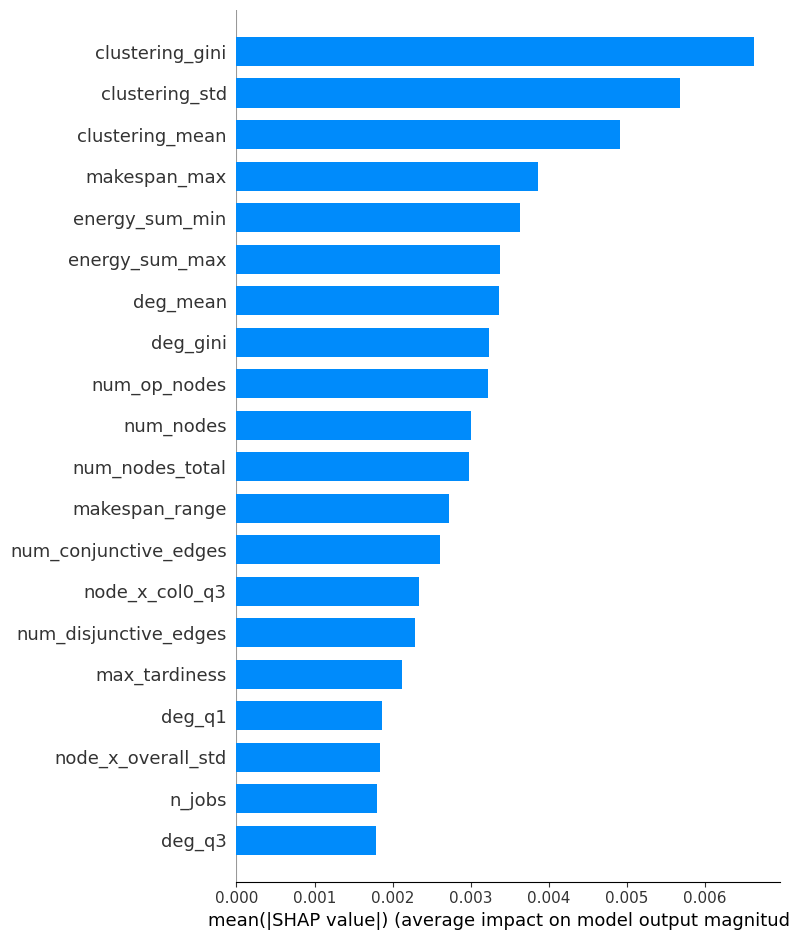

In [ ]:
# Summary bar (global importance)
plt.figure()
shap.summary_plot(
    shap_values,
    features=X_reduced,
    feature_names=feature_names,
    plot_type="bar",
    show=False,
)
plt.tight_layout()
plt.savefig("./figures/shap_summary_bar.png", dpi=200, bbox_inches="tight")
plt.show()

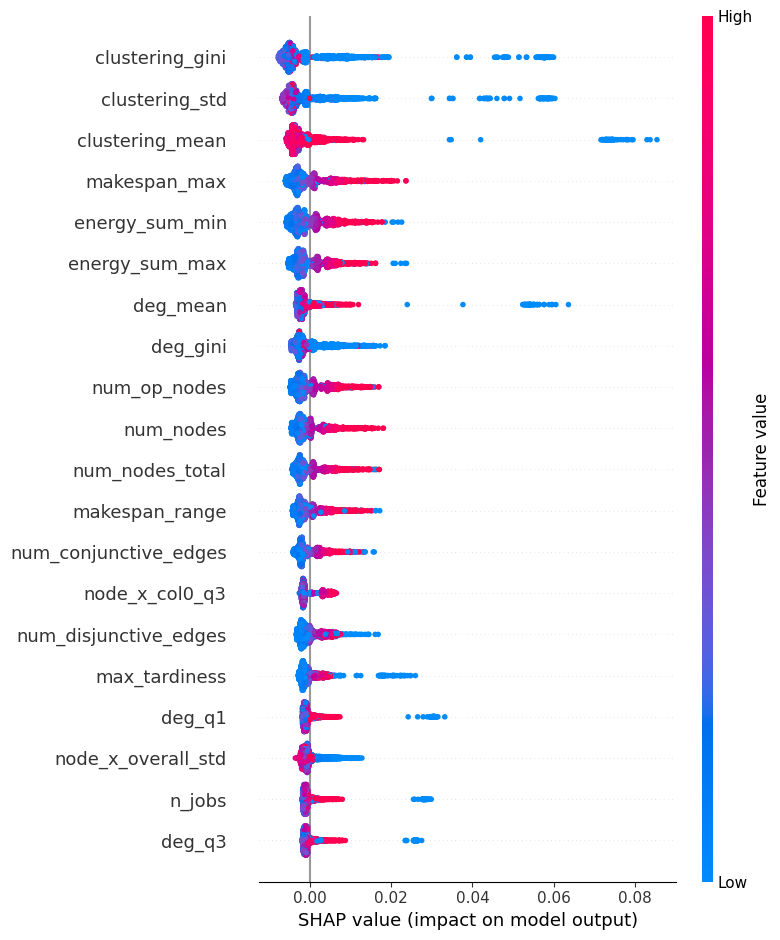

In [ ]:
# Beeswarm (distribution of impacts)
plt.figure()
shap.summary_plot(
    shap_values, features=X_reduced, feature_names=feature_names, show=False
)
plt.tight_layout()
plt.savefig("./figures/shap_summary_beeswarm.png", dpi=200, bbox_inches="tight")
plt.show()

## Dependence Plots

For the **top-6** features, we plot SHAP dependence to visualize how each feature value
influences complexity, and show potential interaction effects automatically.


<Figure size 640x480 with 0 Axes>

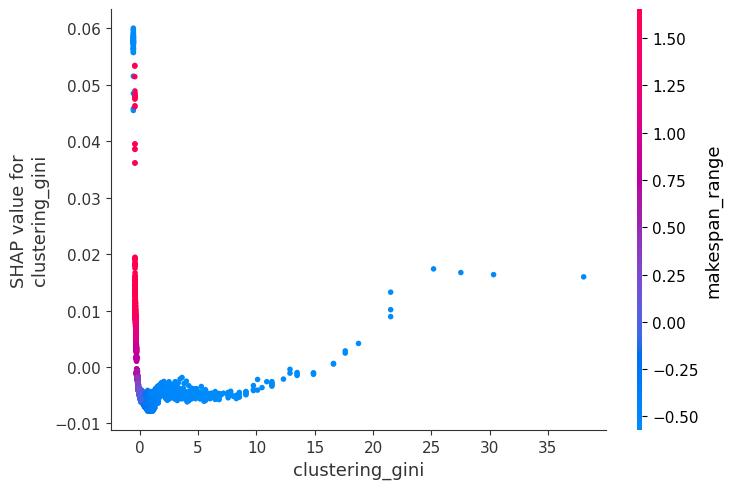

<Figure size 640x480 with 0 Axes>

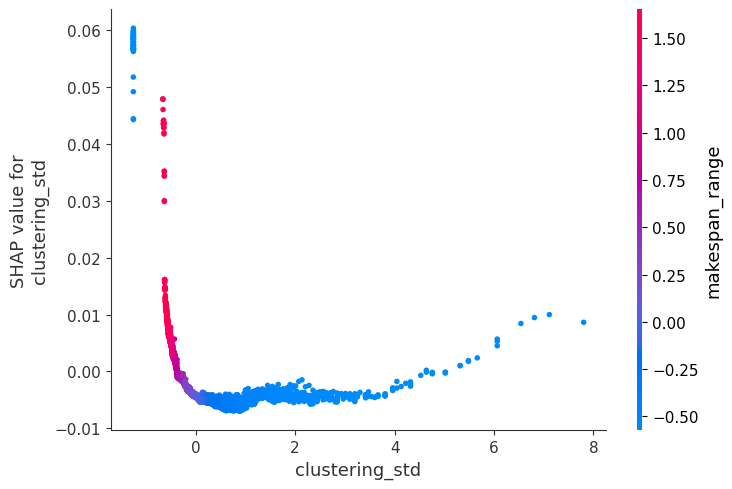

<Figure size 640x480 with 0 Axes>

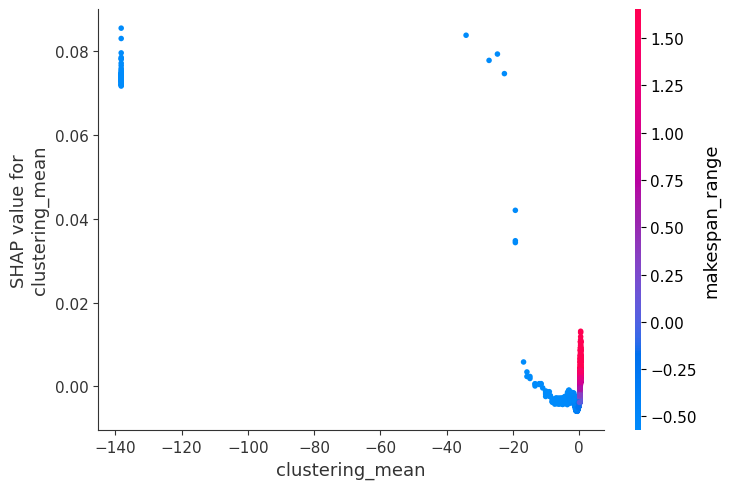

<Figure size 640x480 with 0 Axes>

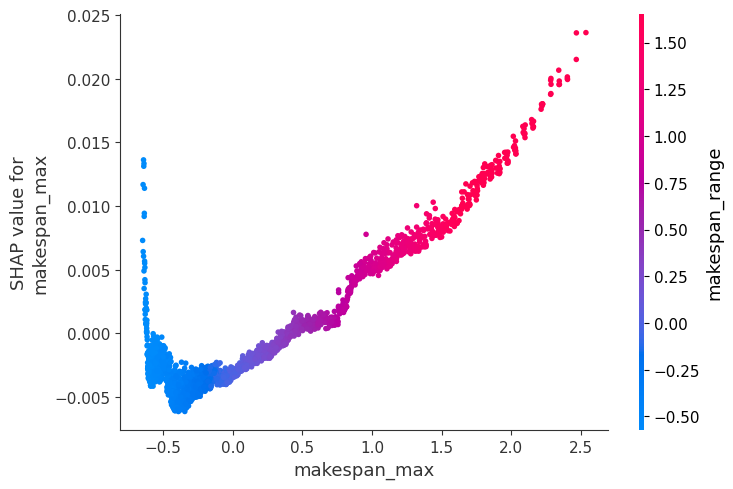

<Figure size 640x480 with 0 Axes>

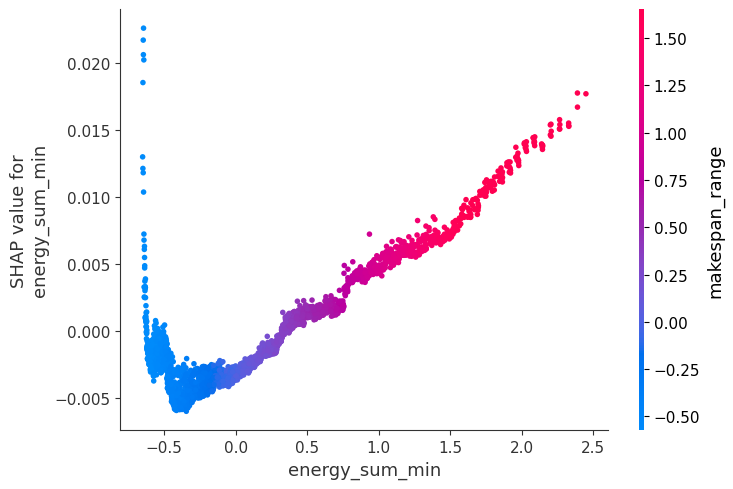

<Figure size 640x480 with 0 Axes>

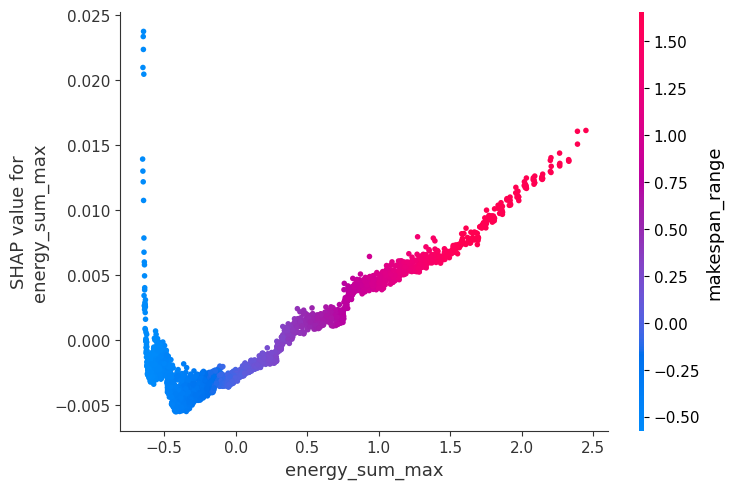

In [ ]:
top_features = abs_importance.head(6).index.tolist()
for feat in top_features:
    plt.figure()
    shap.dependence_plot(
        feat, shap_values, X_reduced, feature_names=feature_names, show=False
    )
    out_path = f"./figures/shap_dependence_{feat}.png"
    plt.tight_layout()
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()

## Export Tables

We export a CSV with mean absolute SHAP value per feature (global importance).


In [ ]:
imp_table = abs_importance.rename("mean_abs_shap")
imp_table.to_csv("./figures/shap_global_importance.csv", header=True)
print("Saved: ./figures/shap_global_importance.csv")

df_shap.to_csv("./figures/shap_values_per_instance.csv")

Saved: ./figures/shap_global_importance.csv


In [ ]:
# Sanity checks: these must exist from the previous notebook
required = [
    "df",
    "X_raw",
    "X_scl",
    "y",
    "rf",
    "explainer",
    "shap_values",
    "feature_names",
]
missing = [v for v in required if v not in globals()]
if missing:
    raise RuntimeError(
        f"Missing variables from previous notebook: {missing}\n"
        "Run the original SHAP notebook first so these are defined."
    )
print("Environment OK. Proceeding with addons...")

Environment OK. Proceeding with addons...


In [ ]:
# Use model predictions to rank instances by complexity
y_pred = rf.predict(X_scl)
order = np.argsort(y_pred)  # ascending: easy -> hard

easy_idx = int(0.05 * len(order)) if len(order) > 20 else 0
median_idx = int(0.50 * len(order))
hard_idx = int(0.95 * len(order)) if len(order) > 20 else len(order) - 1

idx_easy = order[easy_idx]
idx_median = order[median_idx]
idx_hard = order[hard_idx]

ids = df.index.tolist()
sel_ids = [ids[idx_easy], ids[idx_median], ids[idx_hard]]
sel_idxs = [idx_easy, idx_median, idx_hard]

print("Selected instances (easy, median, hard):")
for tag, i in zip(["easy", "median", "hard"], sel_idxs):
    print(f"  {tag}: {ids[i]}  pred={y_pred[i]:.3f}")

Selected instances (easy, median, hard):
  easy: 18-10-0.pt  pred=0.031
  median: 35-26-0.pt  pred=0.108
  hard: 38-49-0.pt  pred=0.297


In [ ]:
base_val = explainer.expected_value
# easy
force_easy = shap.force_plot(
    base_val,
    shap_values[sel_idxs[0]],
    X_reduced[sel_idxs[0]],
    feature_names=feature_names,
    matplotlib=False,
)
# shap.save_html("./figures/shap_force_top_easy.html", force_easy)
# hard
force_hard = shap.force_plot(
    base_val,
    shap_values[sel_idxs[2]],
    X_reduced[sel_idxs[2]],
    feature_names=feature_names,
    matplotlib=False,
)
# shap.save_html("./figures/shap_force_top_hard.html", force_hard)

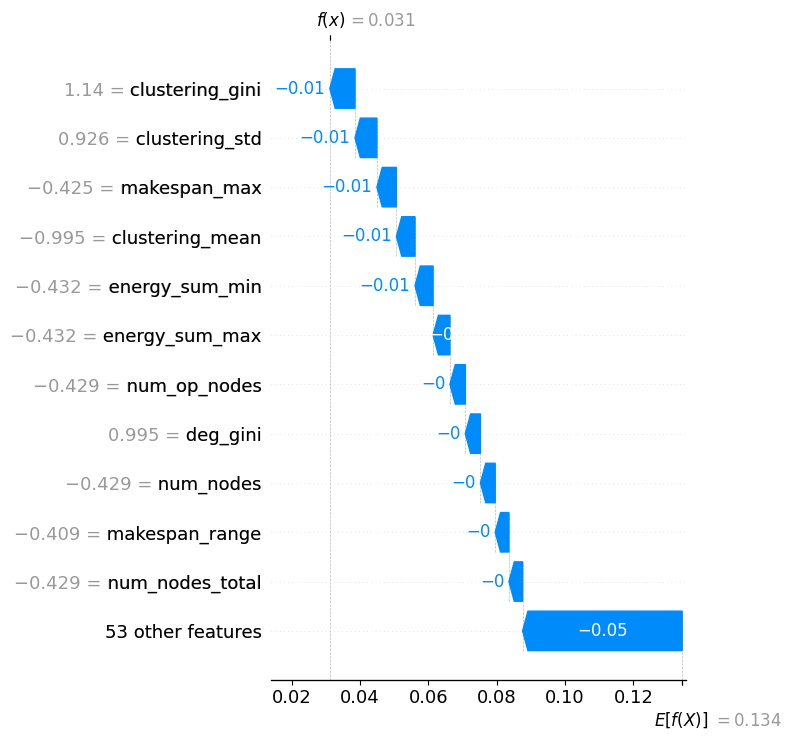

Saved: ./figures/shap_waterfall_easy.png


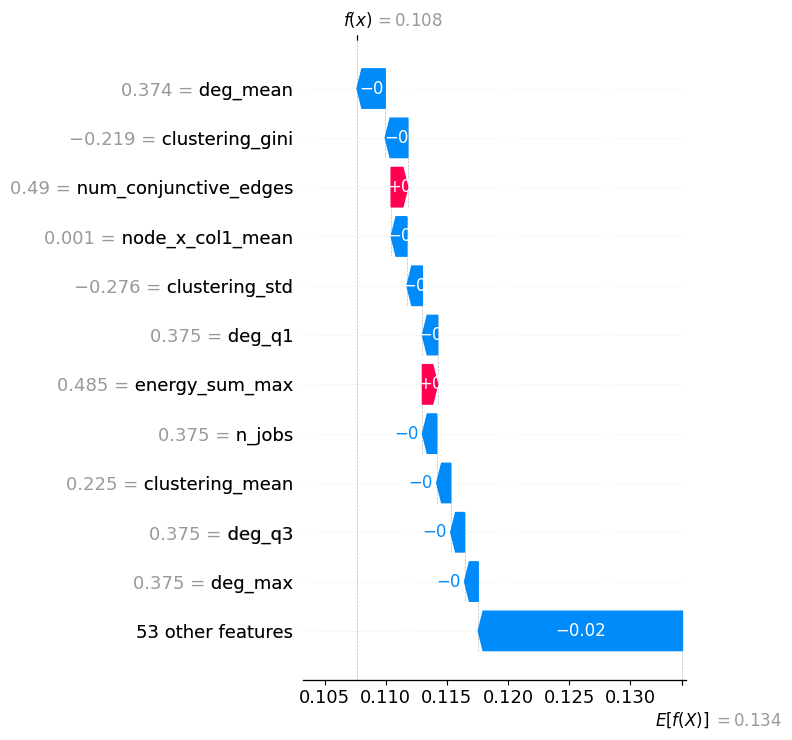

Saved: ./figures/shap_waterfall_median.png


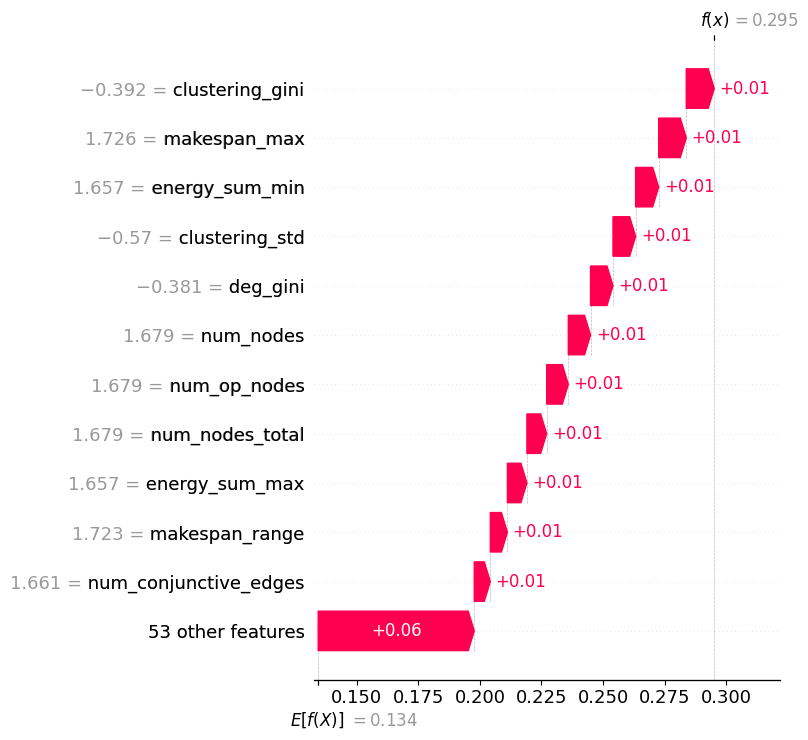

Saved: ./figures/shap_waterfall_hard.png


In [ ]:
def save_waterfall(i, tag):
    exp = shap.Explanation(
        values=shap_values[i],
        base_values=explainer.expected_value,
        data=X_reduced[i],
        feature_names=feature_names,
    )
    plt.figure()
    shap.plots.waterfall(exp, max_display=12, show=False)
    out = f"./figures/shap_waterfall_{tag}.png"
    plt.tight_layout()
    plt.savefig(out, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", out)


for tag, i in zip(["easy", "median", "hard"], sel_idxs):
    save_waterfall(i, tag)

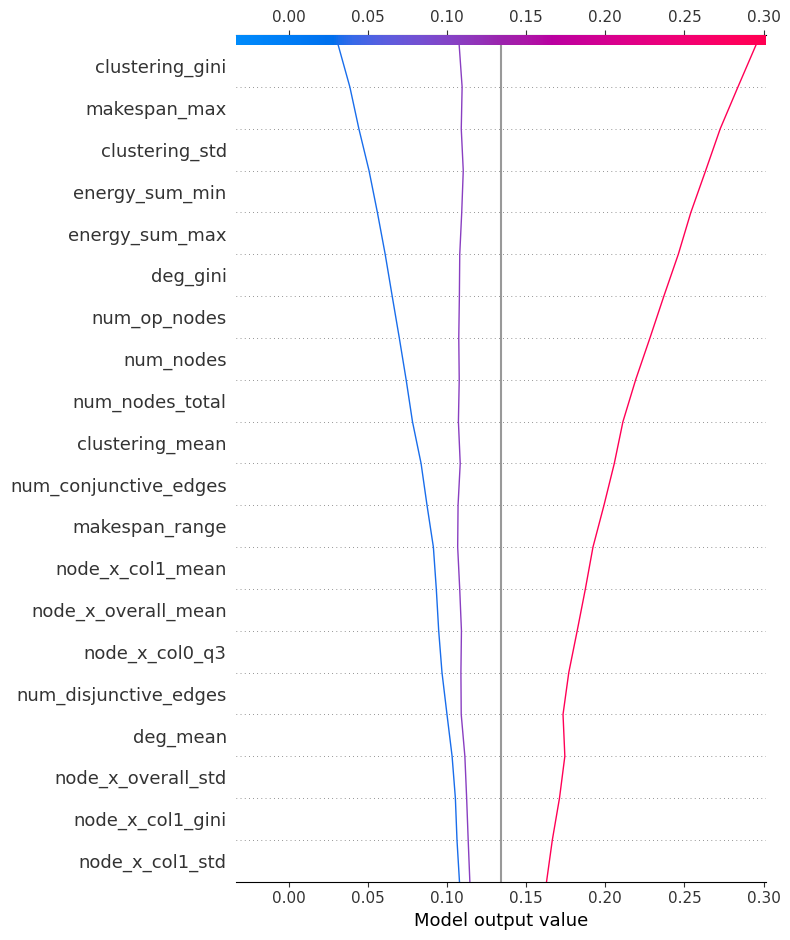

In [ ]:
plt.figure(figsize=(10, 5))
shap.decision_plot(
    explainer.expected_value,
    shap_values[sel_idxs, :],
    feature_names=feature_names,
    link="identity",
    show=False,
)
out = "./figures/shap_decision_selected.png"
plt.tight_layout()
plt.savefig(out, dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values, X_reduced)

NameError: name 'shap' is not defined